In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Segmentation d'images par K-Means

Ce notebook implémente la segmentation d'images par K-Means en réutilisant les mêmes images et la même méthodologie que le notebook de binarisation.

## Chargement des images

In [2]:
# Chemins des images (mêmes que dans binarisation_images.ipynb)
base_path = Path('BD_images')

# Sélection des mêmes images pour comparaison cohérente
images_paths = [
    base_path / 'Voitures_01' / 'image011.jpg',
    base_path / 'Fraises_02' / 'image021.jpg',
    base_path / 'Citrons_03' / 'image031.jpg',
    base_path / 'Fleurs_06' / 'image061.jpg'
]

# Charger les images
images = []
for path in images_paths:
    if path.exists():
        img = cv2.imread(str(path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        images.append((img_rgb, path.parent.name))
    else:
        print(f"Image non trouvée : {path}")

print(f"{len(images)} images chargées")

4 images chargées


## Prétraitement des images (même méthodologie que binarisation)

In [3]:
def pretraiter_image(image_rgb, target_size=(200, 200)):
    """
    Prétraite une image pour la segmentation kmeans.
    
    Parameters:
    -----------
    image_rgb : array RGB
    target_size : tuple
        Taille de redimensionnement (hauteur, largeur)
    
    Returns:
    --------
    image_redim : image redimensionnée en RGB
    image_gris : image en niveaux de gris
    """
    # Redimensionner pour cohérence
    image_redim = cv2.resize(image_rgb, target_size[::-1])
    
    # Convertir en niveaux de gris pour comparaison
    image_gris = cv2.cvtColor(image_redim, cv2.COLOR_RGB2GRAY)
    
    return image_redim, image_gris

# Prétraiter toutes les images
images_preprocessed = []
for img, nom in images:
    img_red, img_gris = pretraiter_image(img)
    images_preprocessed.append((img_red, img_gris, nom))

## Fonction de segmentation K-Means

In [4]:
def segmentation_kmeans(image_rgb, k=3, espace_couleur='rgb', random_state=42):
    """
    Segmente une image par K-Means clustering.
    
    Parameters:
    -----------
    image_rgb : array RGB (H, W, 3)
    k : int
        Nombre de clusters
    espace_couleur : str
        'rgb', 'hsv', ou 'gris'
    random_state : int
        Pour reproductibilité
    
    Returns:
    --------
    image_segmentee : image avec pixels remplacés par centres de clusters
    labels : array de labels (cluster pour chaque pixel)
    centres : centres des clusters
    inertia : inertie (somme des distances)
    """
    h, w = image_rgb.shape[:2]
    
    # Préparer l'espace de couleur
    if espace_couleur == 'hsv':
        img_work = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)
    elif espace_couleur == 'gris':
        img_work = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
        img_work = np.expand_dims(img_work, axis=2)  # (H, W) -> (H, W, 1)
    else:  # rgb
        img_work = image_rgb
    
    # Convertir en matrice (pixels x features)
    X = img_work.reshape(-1, img_work.shape[2]).astype(np.float32)
    
    # K-Means
    kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    labels = kmeans.fit_predict(X)
    centres = kmeans.cluster_centers_.astype(np.uint8)
    inertia = kmeans.inertia_
    
    # Reconstruire l'image segmentée
    image_segmentee = centres[labels].reshape(h, w, img_work.shape[2])
    
    # Reconvertir si nécessaire
    if espace_couleur == 'hsv':
        image_segmentee = cv2.cvtColor(image_segmentee, cv2.COLOR_HSV2RGB)
    elif espace_couleur == 'gris':
        image_segmentee = np.squeeze(image_segmentee, axis=2)
    
    return image_segmentee, labels, centres, inertia

## Fonction de binarisation (pour comparaison avec K-Means)

In [5]:
def binarisation_otsu(image_rgb):
    """
    Binarise une image en niveaux de gris avec la méthode d'Otsu.
    Pour comparaison avec la segmentation K-Means.
    """
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    seuil, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return binary, int(seuil)

# Test avec la première image
img_rgb, img_gris, nom = images_preprocessed[0]
binary, seuil = binarisation_otsu(img_rgb)
print(f"Seuil d'Otsu pour {nom} : {seuil}")

Seuil d'Otsu pour Voitures_01 : 133


## Segmentation K-Means avec différents nombres de clusters

In [6]:
# Paramètres de segmentation
k_values = [2, 3, 4, 5]
espace_couleur = 'rgb'  # rgb, hsv, ou gris
random_state = 42

# Dictionnaire pour stocker les résultats
resultats_kmeans = {}

for img_rgb, img_gris, nom in images_preprocessed:
    print(f"\nSegmentation de {nom}...")
    resultats_kmeans[nom] = {}
    
    for k in k_values:
        seg, labels, centres, inertia = segmentation_kmeans(
            img_rgb, k=k, espace_couleur=espace_couleur, random_state=random_state
        )
        resultats_kmeans[nom][k] = {
            'segmented': seg,
            'labels': labels,
            'centres': centres,
            'inertia': inertia
        }
        print(f"  K={k} - Inertie: {inertia:.2f}")

print("\nSegmentations terminées.")


Segmentation de Voitures_01...
  K=2 - Inertie: 210864656.00
  K=3 - Inertie: 84227728.00
  K=4 - Inertie: 55016588.00
  K=5 - Inertie: 37505264.00

Segmentation de Fraises_02...
  K=2 - Inertie: 82093696.00
  K=3 - Inertie: 44256012.00
  K=4 - Inertie: 32107684.00
  K=5 - Inertie: 22045902.00

Segmentation de Citrons_03...
  K=2 - Inertie: 273399936.00
  K=3 - Inertie: 132683208.00
  K=4 - Inertie: 96272576.00
  K=5 - Inertie: 80297944.00

Segmentation de Fleurs_06...
  K=2 - Inertie: 168326080.00
  K=3 - Inertie: 108198400.00
  K=4 - Inertie: 62321420.00
  K=5 - Inertie: 46117792.00

Segmentations terminées.


## Visualisation : Comparaison Image originale vs Binarisation vs K-Means

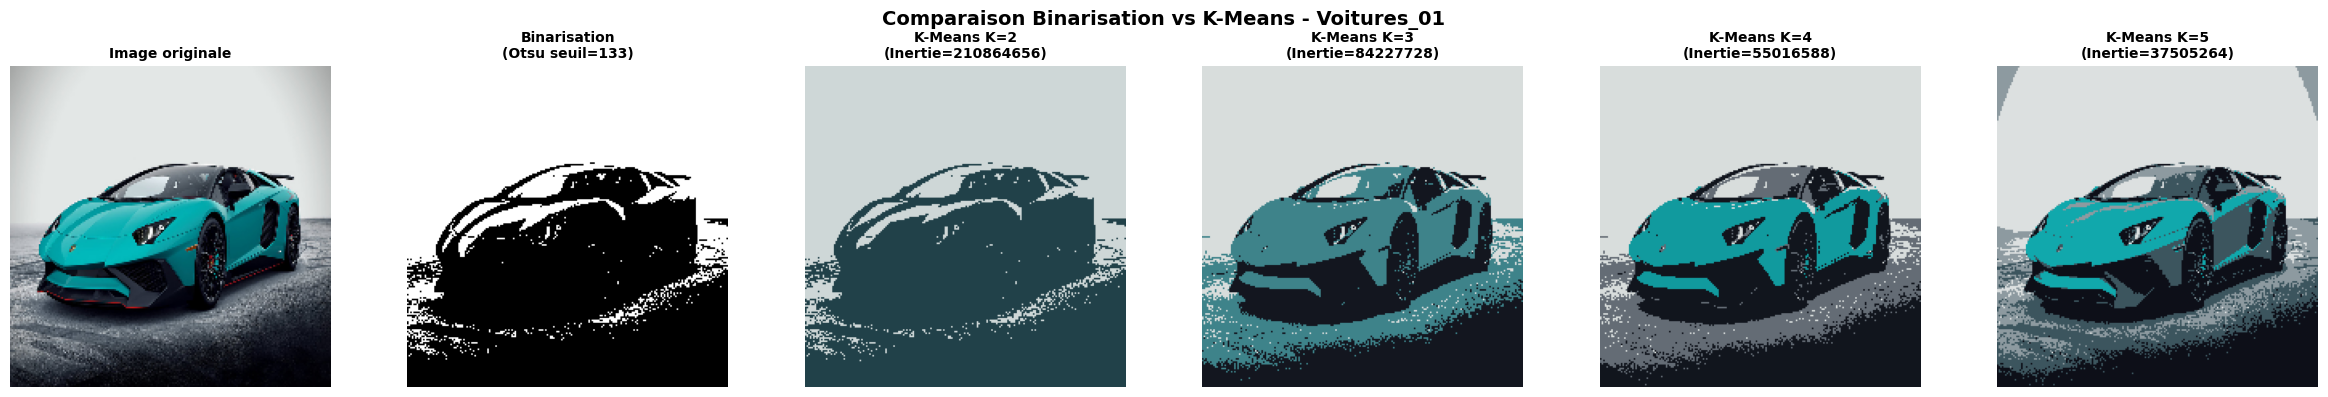

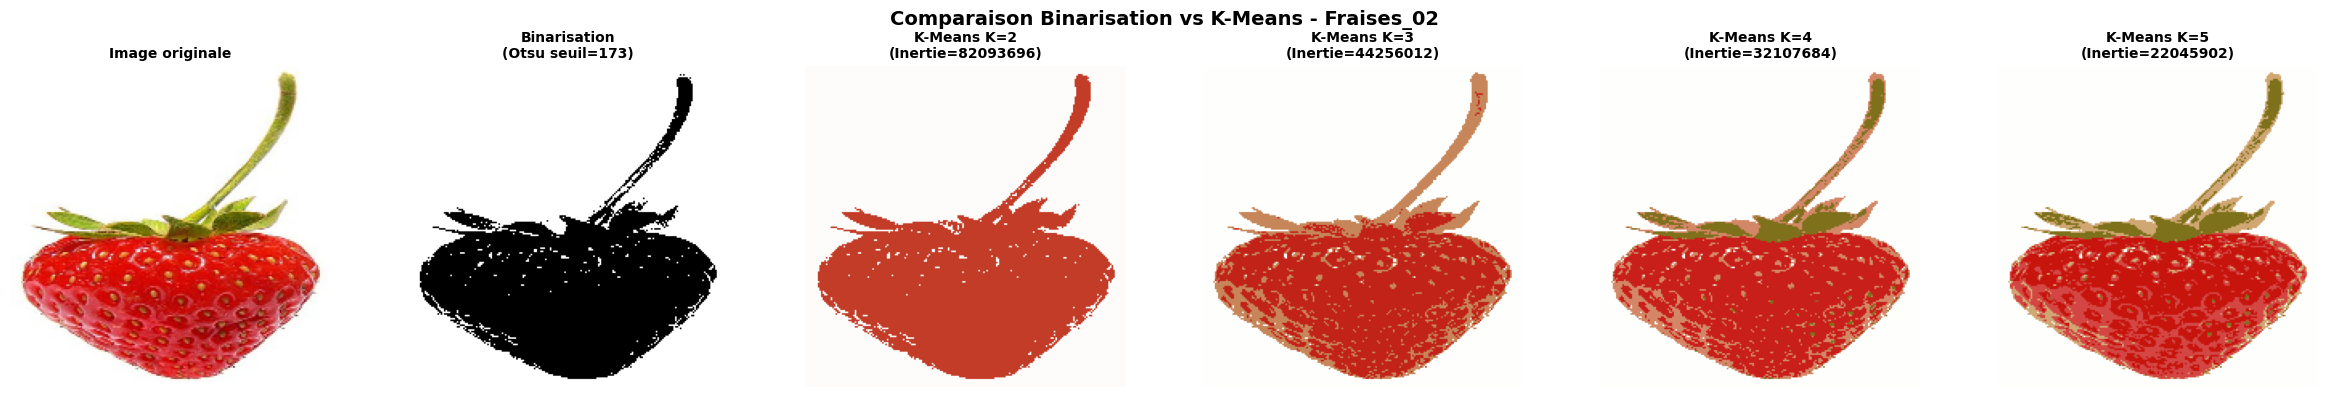

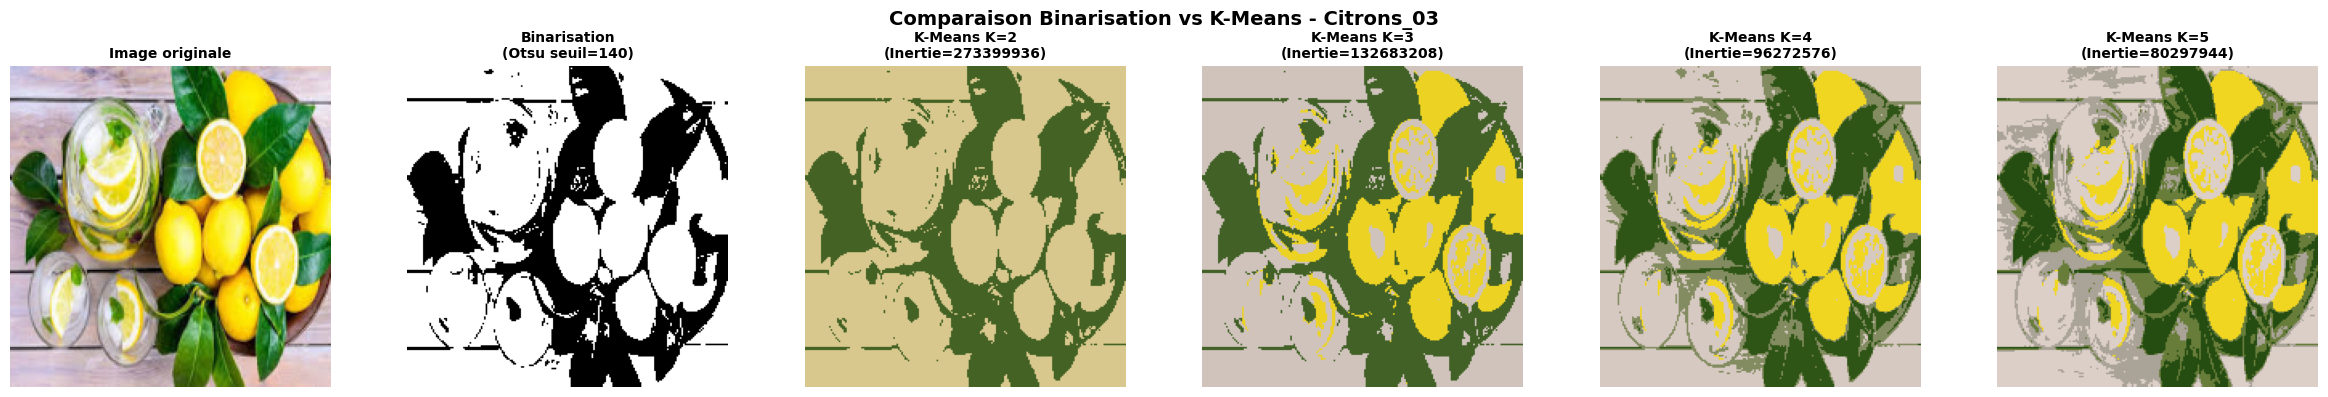

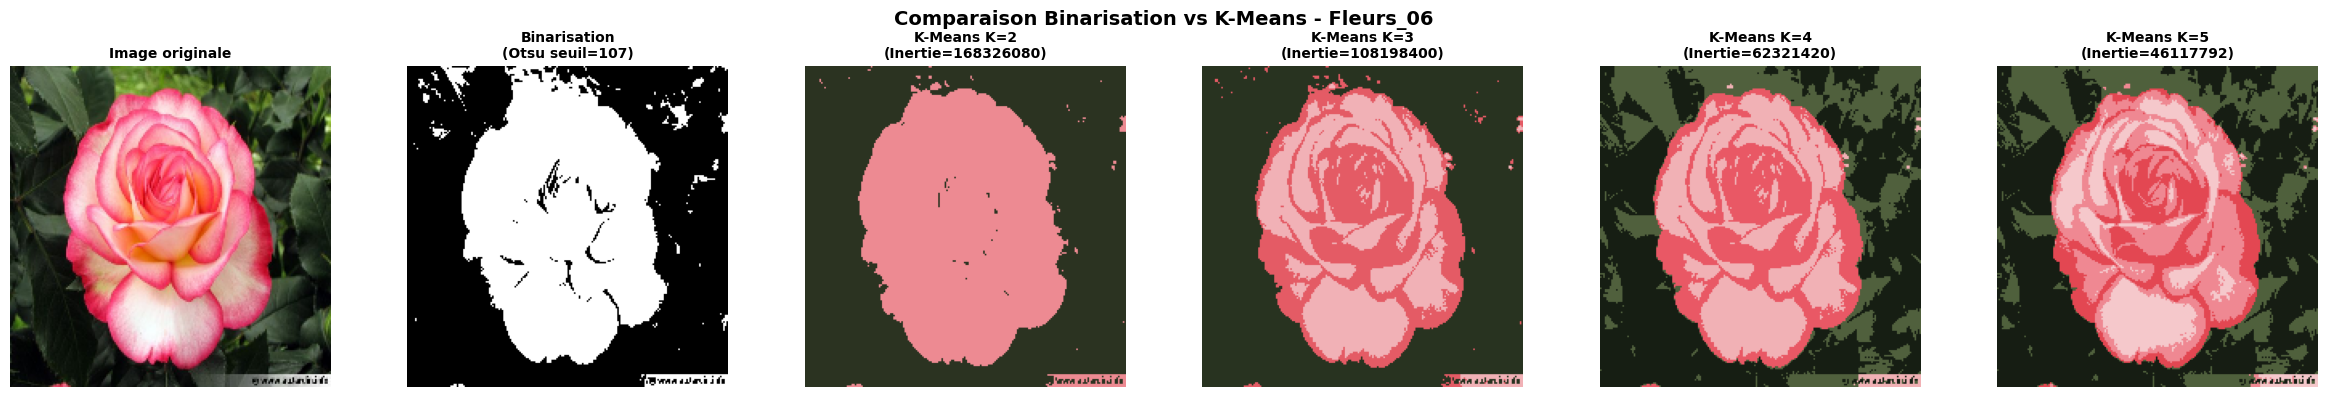

In [7]:
# Visualisation pour chaque image
for img_rgb, img_gris, nom in images_preprocessed:
    # Binarisation pour comparaison
    binary, seuil = binarisation_otsu(img_rgb)
    
    # Créer la figure
    n_cols = len(k_values) + 2  # Image originale + Binarisation + K-Means résultats
    fig, axes = plt.subplots(1, n_cols, figsize=(4*n_cols, 4))
    fig.suptitle(f'Comparaison Binarisation vs K-Means - {nom}', fontsize=14, fontweight='bold')
    
    # Image originale
    axes[0].imshow(img_rgb)
    axes[0].set_title('Image originale', fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Binarisation
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title(f'Binarisation\n(Otsu seuil={seuil})', fontsize=10, fontweight='bold')
    axes[1].axis('off')
    
    # K-Means pour différentes valeurs de k
    for idx, k in enumerate(k_values):
        ax_idx = 2 + idx
        seg_img = resultats_kmeans[nom][k]['segmented']
        inertia = resultats_kmeans[nom][k]['inertia']
        
        # Afficher l'image segmentée (elle est déjà en RGB si espace_couleur='rgb')
        if len(seg_img.shape) == 2:  # Si niveaux de gris
            axes[ax_idx].imshow(seg_img, cmap='gray')
        else:
            axes[ax_idx].imshow(seg_img.astype(np.uint8))
        
        axes[ax_idx].set_title(f'K-Means K={k}\n(Inertie={inertia:.0f})', fontsize=10, fontweight='bold')
        axes[ax_idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## Analyse de l'inertie : Courbe du coude (Elbow Method)

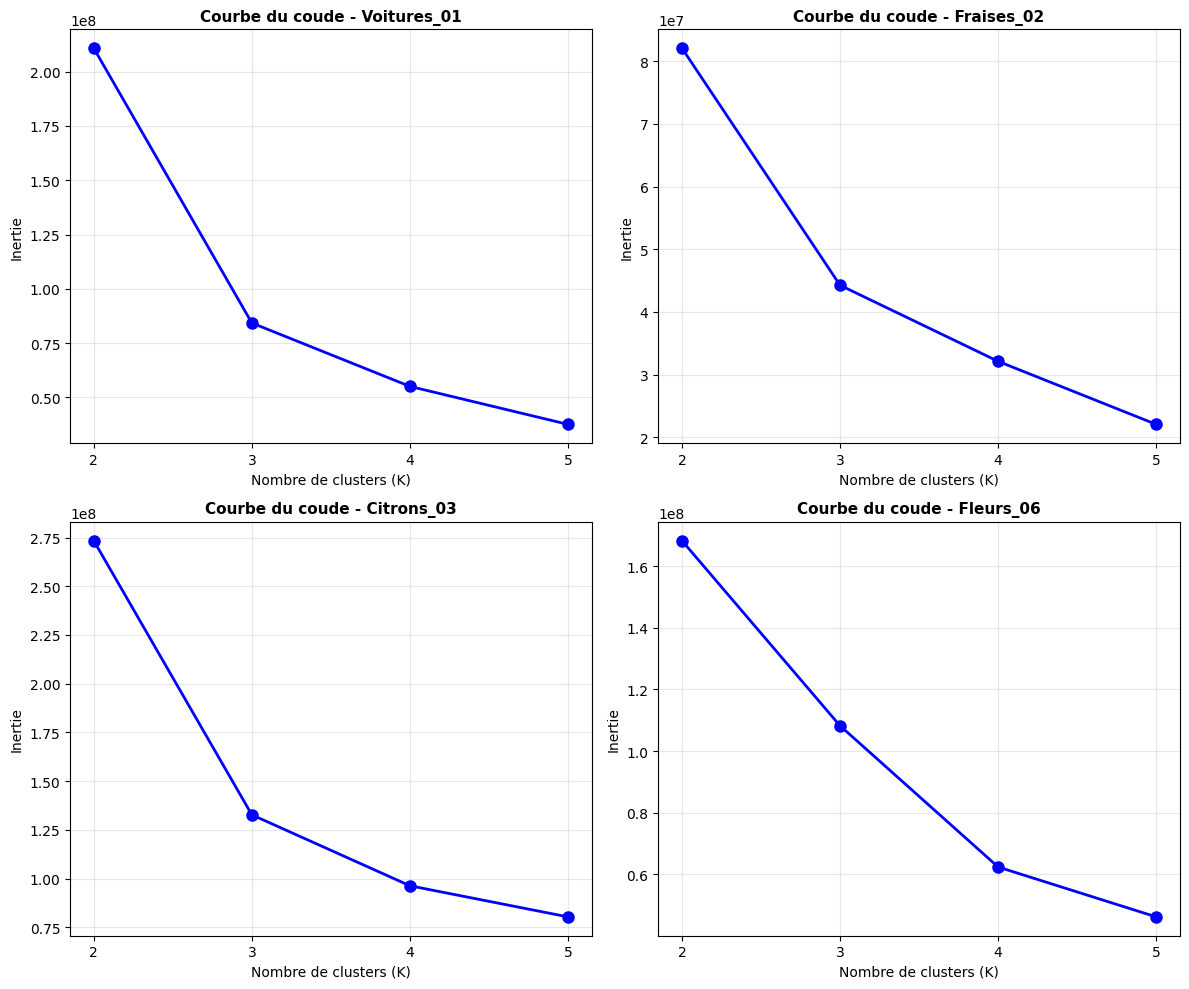

Analyse de l'inertie terminée.


In [8]:
# Analyse de l'inertie pour chaque image
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (img_rgb, img_gris, nom) in enumerate(images_preprocessed):
    inerties = []
    for k in k_values:
        inertia = resultats_kmeans[nom][k]['inertia']
        inerties.append(inertia)
    
    axes[idx].plot(k_values, inerties, 'bo-', linewidth=2, markersize=8)
    axes[idx].set_xlabel('Nombre de clusters (K)', fontsize=10)
    axes[idx].set_ylabel('Inertie', fontsize=10)
    axes[idx].set_title(f'Courbe du coude - {nom}', fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xticks(k_values)

plt.tight_layout()
plt.show()
print("Analyse de l'inertie terminée.")

## Sauvegarde des résultats et résumé des paramètres

In [9]:
# Créer un dossier de sortie pour les résultats
output_dir = Path('resultats_kmeans')
output_dir.mkdir(exist_ok=True)

# Sauvegarder les images segmentées
for img_rgb, img_gris, nom in images_preprocessed:
    for k in k_values:
        seg_img = resultats_kmeans[nom][k]['segmented']
        
        # Assurer que l'image est en uint8
        if seg_img.dtype != np.uint8:
            seg_img = seg_img.astype(np.uint8)
        
        # Convertir en BGR pour cv2.imwrite
        if len(seg_img.shape) == 3:
            seg_img_bgr = cv2.cvtColor(seg_img, cv2.COLOR_RGB2BGR)
        else:  # Niveaux de gris
            seg_img_bgr = seg_img
        
        filename = f"{nom}_kmeans_k{k}.jpg"
        filepath = output_dir / filename
        cv2.imwrite(str(filepath), seg_img_bgr)
        print(f"Sauvegardé : {filepath}")

# Copier aussi les images de binarisation pour comparaison
for img_rgb, img_gris, nom in images_preprocessed:
    binary, _ = binarisation_otsu(img_rgb)
    filename = f"{nom}_binarisation.jpg"
    filepath = output_dir / filename
    cv2.imwrite(str(filepath), binary)
    print(f"Sauvegardé : {filepath}")

print(f"\nTous les résultats sauvegardés dans '{output_dir}'")

Sauvegardé : resultats_kmeans\Voitures_01_kmeans_k2.jpg
Sauvegardé : resultats_kmeans\Voitures_01_kmeans_k3.jpg
Sauvegardé : resultats_kmeans\Voitures_01_kmeans_k4.jpg
Sauvegardé : resultats_kmeans\Voitures_01_kmeans_k5.jpg
Sauvegardé : resultats_kmeans\Fraises_02_kmeans_k2.jpg
Sauvegardé : resultats_kmeans\Fraises_02_kmeans_k3.jpg
Sauvegardé : resultats_kmeans\Fraises_02_kmeans_k4.jpg
Sauvegardé : resultats_kmeans\Fraises_02_kmeans_k5.jpg
Sauvegardé : resultats_kmeans\Citrons_03_kmeans_k2.jpg
Sauvegardé : resultats_kmeans\Citrons_03_kmeans_k3.jpg
Sauvegardé : resultats_kmeans\Citrons_03_kmeans_k4.jpg
Sauvegardé : resultats_kmeans\Citrons_03_kmeans_k5.jpg
Sauvegardé : resultats_kmeans\Fleurs_06_kmeans_k2.jpg
Sauvegardé : resultats_kmeans\Fleurs_06_kmeans_k3.jpg
Sauvegardé : resultats_kmeans\Fleurs_06_kmeans_k4.jpg
Sauvegardé : resultats_kmeans\Fleurs_06_kmeans_k5.jpg
Sauvegardé : resultats_kmeans\Voitures_01_binarisation.jpg
Sauvegardé : resultats_kmeans\Fraises_02_binarisation.jpg
Sau

In [10]:
# Résumé des paramètres et résultats
print("\n" + "="*80)
print("RÉSUMÉ DE LA SEGMENTATION K-MEANS")
print("="*80)

print(f"\nParamètres utilisés:")
print(f"  - Espace de couleur : {espace_couleur.upper()}")
print(f"  - Nombre de clusters testés : {k_values}")
print(f"  - Random state (reproductibilité) : {random_state}")
print(f"  - Nombre d'initialisations (n_init) : 10")

print(f"\nImages traitées:")
for img_rgb, img_gris, nom in images_preprocessed:
    print(f"  - {nom}")

print(f"\nRésultats d'inertie par image et cluster:")
print("-" * 80)
for img_rgb, img_gris, nom in images_preprocessed:
    print(f"\n{nom}:")
    for k in k_values:
        inertia = resultats_kmeans[nom][k]['inertia']
        print(f"  K={k:2d} -> Inertie = {inertia:10.2f}")

print(f"\nRésultats sauvegardés dans : {output_dir}")
print("\nNOTA BENE :")
print("  - Les images K-Means ont remplacé chaque pixel par la couleur du centre du cluster correspondant")
print("  - La binarisation est fournie à titre de comparaison avec les résultats K-Means")
print("  - Pour déterminer le nombre optimal de clusters, observer la 'courbe du coude' (Elbow Method)")
print("="*80)


RÉSUMÉ DE LA SEGMENTATION K-MEANS

Paramètres utilisés:
  - Espace de couleur : RGB
  - Nombre de clusters testés : [2, 3, 4, 5]
  - Random state (reproductibilité) : 42
  - Nombre d'initialisations (n_init) : 10

Images traitées:
  - Voitures_01
  - Fraises_02
  - Citrons_03
  - Fleurs_06

Résultats d'inertie par image et cluster:
--------------------------------------------------------------------------------

Voitures_01:
  K= 2 -> Inertie = 210864656.00
  K= 3 -> Inertie = 84227728.00
  K= 4 -> Inertie = 55016588.00
  K= 5 -> Inertie = 37505264.00

Fraises_02:
  K= 2 -> Inertie = 82093696.00
  K= 3 -> Inertie = 44256012.00
  K= 4 -> Inertie = 32107684.00
  K= 5 -> Inertie = 22045902.00

Citrons_03:
  K= 2 -> Inertie = 273399936.00
  K= 3 -> Inertie = 132683208.00
  K= 4 -> Inertie = 96272576.00
  K= 5 -> Inertie = 80297944.00

Fleurs_06:
  K= 2 -> Inertie = 168326080.00
  K= 3 -> Inertie = 108198400.00
  K= 4 -> Inertie = 62321420.00
  K= 5 -> Inertie = 46117792.00

Résultats sauv

In [11]:
# Résumé des paramètres et résultats
print("\n" + "="*80)
print("RÉSUMÉ DE LA SEGMENTATION K-MEANS")
print("="*80)

print(f"\nParamètres utilisés:")
print(f"  - Espace de couleur : {espace_couleur.upper()}")
print(f"  - Nombre de clusters testés : {k_values}")
print(f"  - Random state (reproductibilité) : {random_state}")
print(f"  - Nombre d'initialisations (n_init) : 10")

print(f"\nImages traitées:")
for img_rgb, img_gris, nom in images_preprocessed:
    print(f"  - {nom}")

print(f"\nRésultats d'inertie par image et cluster:")
print("-" * 80)
for img_rgb, img_gris, nom in images_preprocessed:
    print(f"\n{nom}:")
    for k in k_values:
        inertia = resultats_kmeans[nom][k]['inertia']
        print(f"  K={k:2d} -> Inertie = {inertia:10.2f}")

print(f"\nRésultats sauvegardés dans : {output_dir}")
print("\nNOTA BENE :")
print("  - Les images K-Means ont remplacé chaque pixel par la couleur du centre du cluster correspondant")
print("  - La binarisation est fournie à titre de comparaison avec les résultats K-Means")
print("  - Pour déterminer le nombre optimal de clusters, observer la 'courbe du coude' (Elbow Method)")
print("="*80)


RÉSUMÉ DE LA SEGMENTATION K-MEANS

Paramètres utilisés:
  - Espace de couleur : RGB
  - Nombre de clusters testés : [2, 3, 4, 5]
  - Random state (reproductibilité) : 42
  - Nombre d'initialisations (n_init) : 10

Images traitées:
  - Voitures_01
  - Fraises_02
  - Citrons_03
  - Fleurs_06

Résultats d'inertie par image et cluster:
--------------------------------------------------------------------------------

Voitures_01:
  K= 2 -> Inertie = 210864656.00
  K= 3 -> Inertie = 84227728.00
  K= 4 -> Inertie = 55016588.00
  K= 5 -> Inertie = 37505264.00

Fraises_02:
  K= 2 -> Inertie = 82093696.00
  K= 3 -> Inertie = 44256012.00
  K= 4 -> Inertie = 32107684.00
  K= 5 -> Inertie = 22045902.00

Citrons_03:
  K= 2 -> Inertie = 273399936.00
  K= 3 -> Inertie = 132683208.00
  K= 4 -> Inertie = 96272576.00
  K= 5 -> Inertie = 80297944.00

Fleurs_06:
  K= 2 -> Inertie = 168326080.00
  K= 3 -> Inertie = 108198400.00
  K= 4 -> Inertie = 62321420.00
  K= 5 -> Inertie = 46117792.00

Résultats sauv